In [ ]:

from time import time

import drawsvg as draw
import numpy as np

# Number of steps. Increase this number for larger patches.
# N_ITERATIONS = 0 corresponds to a single spectre tile.
N_ITERATIONS = 2

# count of all tiles. Increment +1 each time a tile is added in function draw in class Tile
num_tiles = 0

IDENTITY = [1, 0, 0, 0, 1, 0]

TILE_NAMES = ["Gamma", "Delta", "Theta", "Lambda", "Xi", "Pi", "Sigma", "Phi", "Psi"]

# Ht metatile == one ODD tile plus three EVEN tiles around
#PINK color
col="rgb(255, 200, 255)" # odd tiles == Gamma and Gamma2
# WHITE color
col_gamma1="rgb(255, 255, 255)" # bottom part of the double mystics == mystics
col_sigma="rgb(255, 255, 255)" # top part of the double mystics
col_delta="rgb(255, 255, 255)" # third tile in Ht metatile which is translated


# theta and lambda goes together
# RED color
col_theta="rgb(255, 0, 0)"
#PURPLE color
col_lambda="rgb(120, 0, 255)"


# ORANGE color
col_xi="rgb(255, 126, 0)"

# two blue colors
# pi and psi togeher: around all local 3-fold L centers
col_pi="rgb(0, 50, 255)" # dark blue
col_psi="rgb(0, 143, 207)" # light blue

# GREEN color
# around all local 3-fold S centers plus some isolated tiles
col_phi="rgb(0, 226, 0)"


COLOR_MAP_ORIG = {
    "Gamma":  col,
    "Gamma1": col_gamma1,
    "Gamma2": col,
    "Delta":  col_delta,
    "Theta":  col_theta,
    "Lambda": col_lambda,
    "Xi":     col_xi,
    "Pi":     col_pi,
    "Sigma":  col_sigma,
    "Phi":    col_phi,
    "Psi":    col_psi
}

COLOR_MAP_MYSTICS = {
	"Gamma":  col,
	"Gamma1": col_gamma1,
	"Gamma2": col,
	"Delta":  col_delta,
	"Theta":  col_theta,
	"Lambda": col_lambda,
	"Xi":     col_xi,
	"Pi":     col_pi,
	"Sigma":  col_sigma,
	"Phi":    col_phi,
	"Psi":    col_psi
}

COLOR_MAP = COLOR_MAP_ORIG

class pt:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.xy = [x, y]

SPECTRE_POINTS = [
    pt(0,                0),
    pt(1.0,              0.0),
    pt(1.5,              -np.sqrt(3)/2),
    pt(1.5+np.sqrt(3)/2, 0.5-np.sqrt(3)/2),
    pt(1.5+np.sqrt(3)/2, 1.5-np.sqrt(3)/2),
    pt(2.5+np.sqrt(3)/2, 1.5-np.sqrt(3)/2),
    pt(3+np.sqrt(3)/2,   1.5),
    pt(3.0,              2.0),
    pt(3-np.sqrt(3)/2,   1.5),
    pt(2.5-np.sqrt(3)/2, 1.5+np.sqrt(3)/2),
    pt(1.5-np.sqrt(3)/2, 1.5+np.sqrt(3)/2),
    pt(0.5-np.sqrt(3)/2, 1.5+np.sqrt(3)/2),
    pt(-np.sqrt(3)/2,    1.5),
    pt(0.0,              1.0)
]

def flatten(lst):
    return [item for sublist in lst for item in sublist]

SPECTRE_SHAPE = draw.Lines(*flatten([p.xy for p in SPECTRE_POINTS]), close=True)

# Affine matrix multiply
def mul(A, B):
    return [
        A[0]*B[0] + A[1]*B[3],
        A[0]*B[1] + A[1]*B[4],
        A[0]*B[2] + A[1]*B[5] + A[2],

        A[3]*B[0] + A[4]*B[3],
        A[3]*B[1] + A[4]*B[4],
        A[3]*B[2] + A[4]*B[5] + A[5]
    ]

# Rotation matrix
def trot(ang):
    c = np.cos(ang)
    s = np.sin(ang)
    return [c, -s, 0, s, c, 0]

# Translation matrix
def ttrans(tx, ty):
    return [1, 0, tx, 0, 1, ty]

def transTo(p, q):
    return ttrans(q.x - p.x, q.y - p.y)

# Matrix * point
def transPt(M, P):
    return pt(M[0]*P.x + M[1]*P.y + M[2], M[3]*P.x + M[4]*P.y + M[5])

def drawPolygon(drawing, T, f, s, w):
    """
    drawing: drawing to draw on
    T: transformation matrix
    f: tile fill color
    s: tile stroke color
    w: tile stroke width
    """

    fill = f
    stroke_f = s
    stroke_w = w if s else 0

    drawing.append(draw.Use(
        SPECTRE_SHAPE,
        0, 0,
        transform=f"matrix({T[0]} {T[3]} {T[1]} {T[4]} {T[2]} {T[5]})",
        fill=fill,
        stroke=stroke_f,
        stroke_width=stroke_w))

class Tile:
    def __init__(self, pts, label):
        """
        pts: list of Tile coordinate points
        label: Tile type used for coloring
        """
        self.quad = [pts[3], pts[5], pts[7], pts[11]]
        self.label = label

    def draw(self, drawing, tile_transformation=IDENTITY):
        global num_tiles
        num_tiles += 1
        return drawPolygon(drawing, tile_transformation, COLOR_MAP[self.label], "black", 0.1)

class MetaTile:
    def __init__(self, geometries=[], quad=[]):
        """
        geometries: list of pairs of (Meta)Tiles and their transformations
        quad: MetaTile quad points
        """
        self.geometries = geometries
        self.quad = quad

    def draw(self, drawing, metatile_transformation=IDENTITY):
        """
        recursively expand MetaTiles down to Tiles and draw those
        """
        # TODO: parallelize?
        [ shape.draw(drawing, mul(metatile_transformation, shape_transformation)) for shape, shape_transformation in self.geometries ]


#def draw_shape(shape_data):
#    drawing, metatile_transformation, shape, shape_transformation = shape_data
#    return shape.draw(drawing, mul(metatile_transformation, shape_transformation))

def buildSpectreBase():
    spectre_base_cluster = { label: Tile(SPECTRE_POINTS, label) for label in TILE_NAMES if label != "Gamma" }
    # special rule for Gamma
    mystic = MetaTile(
        [
            [Tile(SPECTRE_POINTS, "Gamma1"), IDENTITY],
            [Tile(SPECTRE_POINTS, "Gamma2"), mul(ttrans(SPECTRE_POINTS[8].x, SPECTRE_POINTS[8].y), trot(np.pi/6))]
        ],
        [SPECTRE_POINTS[3], SPECTRE_POINTS[5], SPECTRE_POINTS[7], SPECTRE_POINTS[11]]
    )
    spectre_base_cluster["Gamma"] = mystic

    return spectre_base_cluster

def buildSupertiles(tileSystem):
    """
    iteratively build on current system of tiles
    tileSystem = current system of tiles, initially built with buildSpectreBase()
    """

    # First, use any of the nine-unit tiles in tileSystem to obtain
    # a list of transformation matrices for placing tiles within
    # supertiles.
    quad = tileSystem["Delta"].quad
    R = [-1, 0, 0, 0, 1, 0]

    """
    [rotation angle, starting quad point, target quad point]
    """
    transformation_rules = [
        [60, 3, 1], [0, 2, 0], [60, 3, 1], [60, 3, 1],
        [0, 2, 0], [60, 3, 1], [-120, 3, 3]
    ]

    transformations = [IDENTITY]
    total_angle = 0
    rotation = IDENTITY
    transformed_quad = list(quad)

    for _angle, _from, _to in transformation_rules:
        if(_angle != 0):
            total_angle += _angle
            rotation = trot(np.deg2rad(total_angle))
            transformed_quad = [ transPt(rotation, quad_pt) for quad_pt in quad ]

        ttt = transTo(
            transformed_quad[_to],
            transPt(transformations[-1], quad[_from])
        )
        transformations.append(mul(ttt, rotation))

    transformations = [ mul(R, transformation) for transformation in transformations ]

    # Now build the actual supertiles, labelling appropriately.
    super_rules = {
        "Gamma":  ["Pi",  "Delta", None,  "Theta", "Sigma", "Xi",  "Phi",    "Gamma"],
        "Delta":  ["Xi",  "Delta", "Xi",  "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Theta":  ["Psi", "Delta", "Pi",  "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Lambda": ["Psi", "Delta", "Xi",  "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Xi":     ["Psi", "Delta", "Pi",  "Phi",   "Sigma", "Psi", "Phi",    "Gamma"],
        "Pi":     ["Psi", "Delta", "Xi",  "Phi",   "Sigma", "Psi", "Phi",    "Gamma"],
        "Sigma":  ["Xi",  "Delta", "Xi",  "Phi",   "Sigma", "Pi",  "Lambda", "Gamma"],
        "Phi":    ["Psi", "Delta", "Psi", "Phi",   "Sigma", "Pi",  "Phi",    "Gamma"],
        "Psi":    ["Psi", "Delta", "Psi", "Phi",   "Sigma", "Psi", "Phi",    "Gamma"]
    }
    super_quad = [
        transPt(transformations[6], quad[2]),
        transPt(transformations[5], quad[1]),
        transPt(transformations[3], quad[2]),
        transPt(transformations[0], quad[1])
    ]

    return {
        label: MetaTile(
            [ [tileSystem[substitution], transformation] for substitution, transformation in zip(substitutions, transformations) if substitution ],
            super_quad
        ) for label, substitutions in super_rules.items() }



In [5]:
start = time()
shapes = buildSpectreBase()
for _ in range(N_ITERATIONS):
    shapes = buildSupertiles(shapes)
time1 = time()-start
print(f"supertiling loop took {round(time1, 4)} seconds")

d = draw.Drawing(50, 50, origin="center")

# choice of the initial tile for substitution among 6 possible choices:
initile="Psi"
#initile="Pi"
#initile="Phi"
#initile="Theta"
#initile="Xi"
#initile="Lambda"

start = time()

shapes[initile].draw(d)
#shapes["Delta"].draw(d)
time2 = time()-start
print(f"tile recursion loop took {round(time2, 4)} seconds, generated {num_tiles} tiles")

start = time()


path=r'.\svg-spectre'
svg_file=path+r'\spectre-all-colors'+'-'+initile+'-'+str(N_ITERATIONS)+'-iterations'+'.svg'


d.save_svg(svg_file)

time3 = time()-start
print(f"SVG drawing took {round(time3, 4)} seconds")
print(f"total processing time {round(time1+time2+time3, 4)} seconds, {round(1000000*(time1+time2+time3)/num_tiles, 4)} μs/tile")

supertiling loop took 0.001 seconds
tile recursion loop took 0.004 seconds, generated 71 tiles
SVG drawing took 0.004 seconds
total processing time 0.0089 seconds, 126.0328 μs/tile


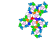

In [6]:
d